In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('../data/raw/amazon_ecommerce_1M.csv')

In [4]:
df.head()

,user_id,product_id,category,subcategory,brand,price,discount,final_price,rating,review_count,stock,seller_id,seller_rating,purchase_date,shipping_time_days,location,device,payment_method,is_returned,delivery_status
0,U356787,P39256,Electronics,Mobile,H&M,33090.51,10.46,29629.31,4.9,43,71,S2679,4.3,2025-03-04,6,Bangalore,Tablet,UPI,True,Returned
1,U198246,P38657,Sports,Outdoor,Samsung,9368.97,5.32,8870.73,3.9,13,119,S9279,4.9,2025-12-12,1,Delhi,Tablet,UPI,True,Returned
2,U539898,P38893,Sports,Fitness,H&M,14756.85,26.00,10919.43,4.2,46,229,S5557,4.9,2024-04-25,1,Chennai,Mobile App,Credit Card,True,Returned
3,U325772,P54118,Beauty,Makeup,Sony,668.83,24.81,502.91,3.8,6,52,S2519,3.1,2025-12-18,2,Mumbai,Web,UPI,False,In Transit
4,U865179,P70217,Home,Decor,Sony,10881.29,48.63,5589.58,4.0,48,274,S3045,2.6,2024-05-16,5,Delhi,Web,UPI,False,Delayed


In [5]:
df.shape

(1000000, 20)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 20 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   user_id             1000000 non-null  str    
 1   product_id          1000000 non-null  str    
 2   category            1000000 non-null  str    
 3   subcategory         1000000 non-null  str    
 4   brand               1000000 non-null  str    
 5   price               1000000 non-null  float64
 6   discount            1000000 non-null  float64
 7   final_price         1000000 non-null  float64
 8   rating              1000000 non-null  float64
 9   review_count        1000000 non-null  int64  
 10  stock               1000000 non-null  int64  
 11  seller_id           1000000 non-null  str    
 12  seller_rating       1000000 non-null  float64
 13  purchase_date       1000000 non-null  str    
 14  shipping_time_days  1000000 non-null  int64  
 15  location            1000000

In [7]:
df.describe()

,price,discount,final_price,rating,review_count,stock,seller_rating,shipping_time_days
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,13224.119093,28.996161,9938.876985,3.927226,32.626704,250.023345,3.750030,3.166389
std,18079.626921,14.681077,14271.885557,0.519443,43.382201,144.567038,0.722092,1.674178
min,200.030000,5.000000,101.460000,1.500000,0.000000,0.000000,2.500000,1.000000
25%,2700.147500,16.910000,1705.930000,3.600000,10.000000,125.000000,3.100000,2.000000
50%,4971.830000,28.070000,3790.795000,3.900000,20.000000,250.000000,3.800000,3.000000
75%,14134.482500,39.240000,10384.440000,4.300000,39.000000,375.000000,4.400000,5.000000
max,79999.700000,70.000000,75831.110000,5.000000,3408.000000,500.000000,5.000000,6.000000


In [8]:
df.isnull().sum().sort_values(ascending=False)

user_id               0
product_id            0
category              0
subcategory           0
brand                 0
price                 0
discount              0
final_price           0
rating                0
review_count          0
stock                 0
seller_id             0
seller_rating         0
purchase_date         0
shipping_time_days    0
location              0
device                0
payment_method        0
is_returned           0
delivery_status       0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.columns

Index(['user_id', 'product_id', 'category', 'subcategory', 'brand', 'price',
       'discount', 'final_price', 'rating', 'review_count', 'stock',
       'seller_id', 'seller_rating', 'purchase_date', 'shipping_time_days',
       'location', 'device', 'payment_method', 'is_returned',
       'delivery_status'],
      dtype='str')

In [12]:
df['purchase_date'] = pd.to_datetime(df['purchase_date'])

## Feature Engineering
creating columns according to months, year, day, name of day and weekly order patterns help:

- identify seasonality
- analyze peak demand
- improve forecasting
- study customer ordering behavior and operational cycles

In [24]:
df['purchase_month'] = df['purchase_date'].dt.month
df['purchase_year'] = df['purchase_date'].dt.year
df['purchase_day'] = df['purchase_date'].dt.day
df['Day_Name'] = df['purchase_date'].dt.day_name()
df['week_number'] = df['purchase_date'].dt.isocalendar().week

Revenue Column will later on be used for :
- forecasting
- KPI analysis
- Tableau dashboards

In [25]:
df['revenue'] = df['final_price']

Creating an Inventory risk variable
- LOGIC- Low stock + High demand = Inventory risk
- This simulates potential stockout exposure

In [26]:
df['inventory_risk'] = np.where(df['stock'] < 50,
                                'High Risk',
                                'Low Risk')

Engineering a Shipping Performance Flag feature to check shipping speed(Fast or slow):

Fast shipping:
- improves customer satisfaction
- reduces cancellation risk
- improves competitiveness

In [27]:
df['shipping_performance'] = np.where(
    df['shipping_time_days'] <= 3,
    'Fast',
    'Slow'
)

Creating a Return Flag Feature to help analyse:
- operational risk
- category quality
- logistics performance

In [28]:
df['return_flag'] = df['is_returned'].astype(int)

In [38]:
df.head()

,user_id,product_id,category,subcategory,brand,price,discount,final_price,rating,review_count,stock,seller_id,seller_rating,purchase_date,shipping_time_days,location,device,payment_method,is_returned,delivery_status,purchase_month,purchase_year,purchase_day,Day_Name,week_number,revenue,inventory_risk,shipping_performance,return_flag
0,U356787,P39256,Electronics,Mobile,H&M,33090.51,10.46,29629.31,4.9,43,71,S2679,4.3,2025-03-04,6,Bangalore,Tablet,UPI,True,Returned,3,2025,4,Tuesday,10,29629.31,Low Risk,Slow,1
1,U198246,P38657,Sports,Outdoor,Samsung,9368.97,5.32,8870.73,3.9,13,119,S9279,4.9,2025-12-12,1,Delhi,Tablet,UPI,True,Returned,12,2025,12,Friday,50,8870.73,Low Risk,Fast,1
2,U539898,P38893,Sports,Fitness,H&M,14756.85,26.00,10919.43,4.2,46,229,S5557,4.9,2024-04-25,1,Chennai,Mobile App,Credit Card,True,Returned,4,2024,25,Thursday,17,10919.43,Low Risk,Fast,1
3,U325772,P54118,Beauty,Makeup,Sony,668.83,24.81,502.91,3.8,6,52,S2519,3.1,2025-12-18,2,Mumbai,Web,UPI,False,In Transit,12,2025,18,Thursday,51,502.91,Low Risk,Fast,0
4,U865179,P70217,Home,Decor,Sony,10881.29,48.63,5589.58,4.0,48,274,S3045,2.6,2024-05-16,5,Delhi,Web,UPI,False,Delayed,5,2024,16,Thursday,20,5589.58,Low Risk,Slow,0


EDA

Analysing Demand Trend Over Time (Using graph)

In [29]:
daily_orders = (
    df.groupby('purchase_date')
    .size()
    .reset_index(name='total_orders')
)

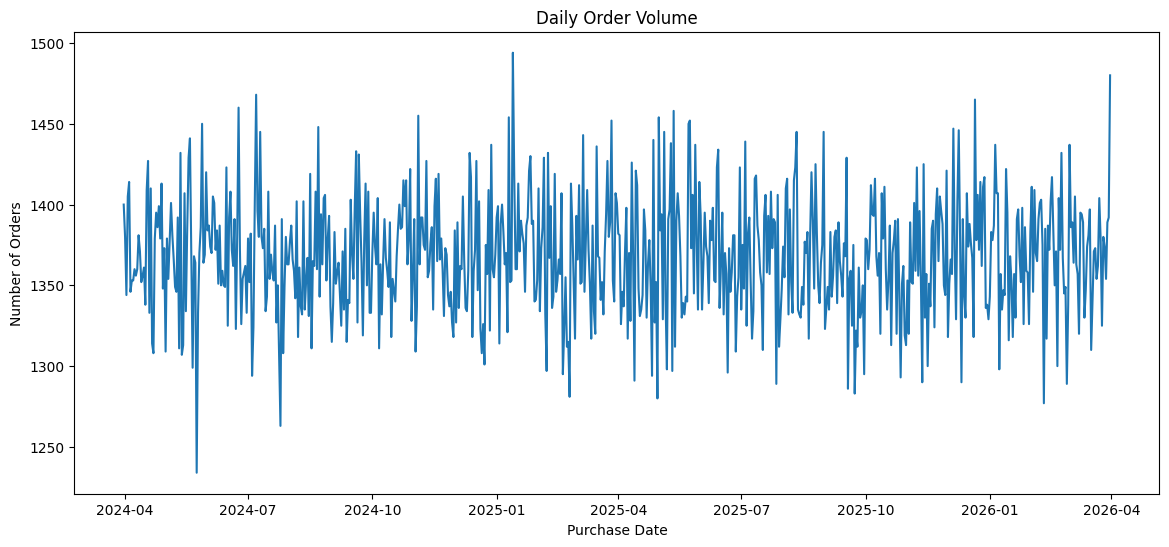

In [30]:
plt.figure(figsize=(14,6))

plt.plot(
    daily_orders['purchase_date'],
    daily_orders['total_orders']
)

plt.title('Daily Order Volume')
plt.xlabel('Purchase Date')
plt.ylabel('Number of Orders')

plt.show()

The above chart helps identify:
- trends
- demand growth
- operational peaks
- seasonality

“The noticeable Order fluctuations indicate customer demand variabilty over time, highlighting the need for a dynamic inventory planning.”

In a Supply chain system, this can be used for further:
- workforce planning
- inventory planning
- warehouse capacity decisions

In [31]:
category_sales = (
    df.groupby('category')['revenue']
    .sum()
    .sort_values(ascending=False)
)

category_sales

category
Electronics    6.579048e+09
Home           1.529978e+09
Sports         1.124849e+09
Beauty         3.759517e+08
Clothing       3.290504e+08
Name: revenue, dtype: float64

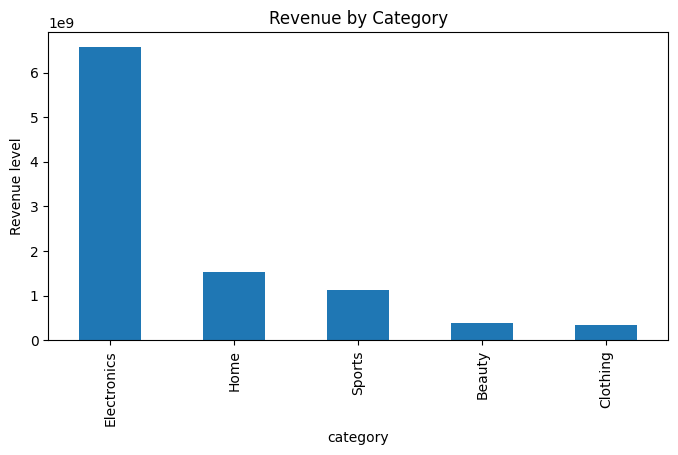

In [42]:
plt.figure(figsize=(8,4))

category_sales.plot(kind='bar')

plt.title('Revenue by Category')
plt.ylabel('Revenue level')

plt.show()

The chart above indicates High revenue-generating categories may require:

- larger safety stock
- stronger supplier coordination
- priority warehouse allocation

The revenue axis is simplified for display purposes due to large amount of total revenue(1e9 representing figures in billions- nine(9) zeros)

In [39]:
top_subcategories = (
    df.groupby('subcategory')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_subcategories

subcategory
Mobile        1.657298e+09
Laptop        1.652686e+09
Headphones    1.637538e+09
Camera        1.631526e+09
Decor         5.125229e+08
Kitchen       5.109966e+08
Furniture     5.064581e+08
Outdoor       3.769483e+08
Fitness       3.750556e+08
Cycling       3.728452e+08
Name: revenue, dtype: float64

The chart below also displays the sub-categories that generate the most revenue over time.

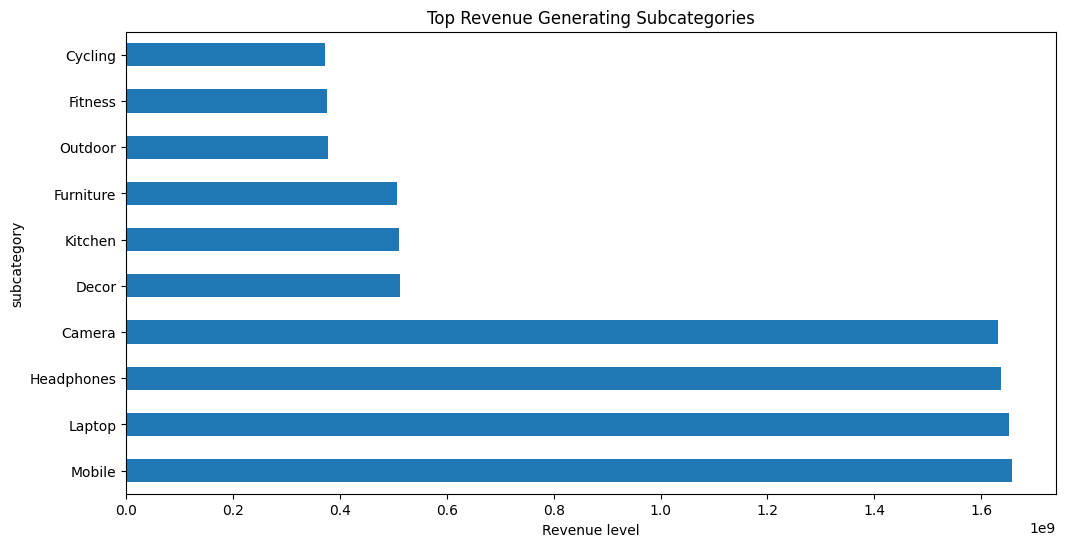

In [43]:
plt.figure(figsize=(12,6))

top_subcategories.plot(kind='barh')

plt.title('Top Revenue Generating Subcategories')
plt.xlabel('Revenue level')

plt.show()

In [44]:
shipping_by_category = (
    df.groupby('category')['shipping_time_days']
    .mean()
    .sort_values()
)

shipping_by_category

category
Clothing       3.161943
Electronics    3.164849
Beauty         3.167800
Sports         3.167973
Home           3.169369
Name: shipping_time_days, dtype: float64

The chart below shows an average of 3.16 shipping days across all product categories, indicating a good enough shipping timing but not "fast".

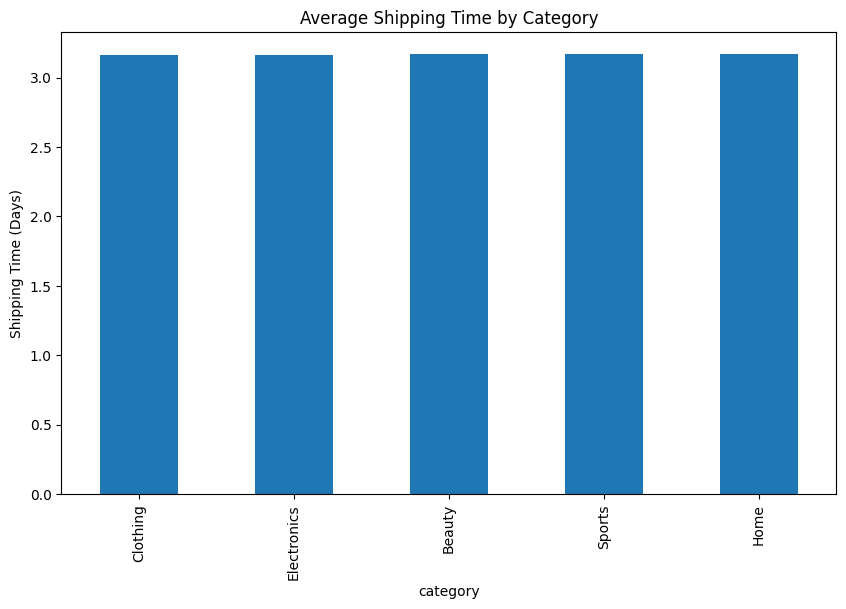

In [45]:
plt.figure(figsize=(10,6))

shipping_by_category.plot(kind='bar')

plt.title('Average Shipping Time by Category')
plt.ylabel('Shipping Time (Days)')

plt.show()

Orders By Location

In [46]:
location_orders = (
    df['location']
    .value_counts()
    .head(10)
)

location_orders

location
Delhi        200649
Bangalore    200270
Chennai      199902
Mumbai       199874
Hyderabad    199305
Name: count, dtype: int64

The chart below indicates the total amount of orders made per location. Regional demand concentration helps:
- allocate inventory strategically
- optimize warehouse positioning
- improve transportation planning

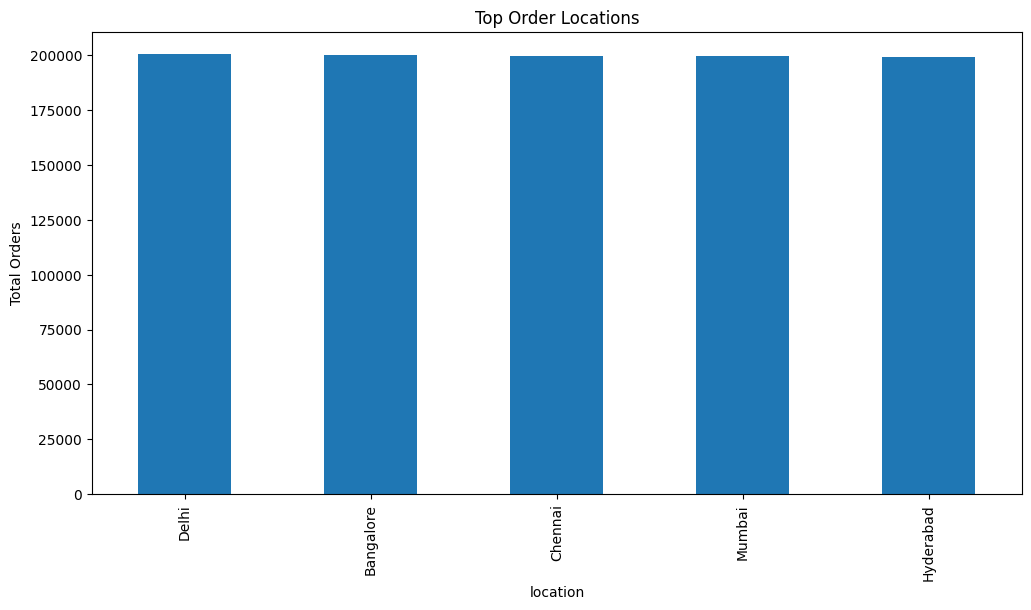

In [47]:
plt.figure(figsize=(12,6))

location_orders.plot(kind='bar')

plt.title('Top Order Locations')

plt.ylabel('Total Orders')

plt.show()

Return Rate Analysis (By Category)

In [51]:
return_rate = (
    df.groupby('category')['return_flag']
    .mean()
    .sort_values(ascending=False)
    * 100
)

return_rate

category
Beauty         11.756059
Clothing       11.736328
Sports         11.645964
Home           11.584097
Electronics    11.273358
Name: return_flag, dtype: float64

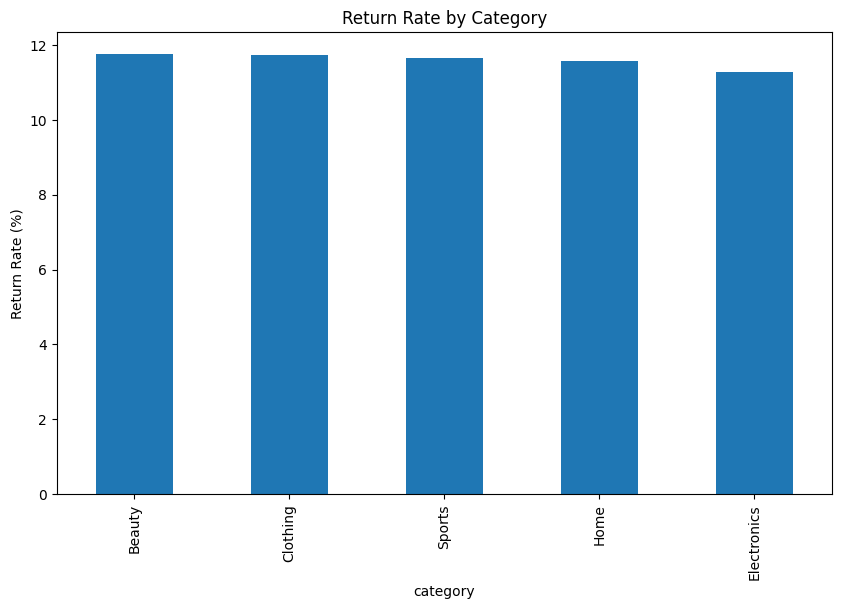

In [52]:
plt.figure(figsize=(10,6))

return_rate.plot(kind='bar')

plt.title('Return Rate by Category')
plt.ylabel('Return Rate (%)')

plt.show()

Returns are a major logistics cost

High return rates may indicate:
- poor product quality
- inaccurate product descriptions
- fulfillment issues
- customer dissatisfaction

Returns create:
- reverse logistics cost
- warehouse burden
- profit loss

- Beauty         11.756059%
- Clothing       11.736328%
- Sports         11.645964%
- Home           11.584097%
- Electronics    11.273358%